# California Housing â€” Boostwatch Analysis (CatBoost)

Regression on the [California Housing](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset) dataset using **CatBoost** â€” demonstrating boostwatch's two-tier monitoring approach for frameworks with limited training-time introspection.

| Property | Value |
|---|---|
| **Rows** | 20,640 |
| **Features** | 8 (all continuous) |
| **Task** | Regression â€” predict median house value ($100K units) |
| **Framework** | CatBoost 1.x |
| **Source** | 1990 California Census via `sklearn.datasets.fetch_california_housing` |

## CatBoost & Boostwatch: Two-tier Monitoring

CatBoost does not expose full tree structure through training callbacks. Boostwatch uses a **two-tier approach**:

1. **Live metrics** â€” `observer.callbacks()` captures eval metrics at every iteration during training
2. **Post-fit tree structure** â€” `observer.finalize(model)` extracts tree leaf counts and feature importance after `model.fit()` completes

## What this notebook covers
1. Downloading & exploring the dataset
2. CatBoost regression with boostwatch (live metrics + finalize)
3. Feature importance from boostwatch vs CatBoost built-in
4. Tree complexity and leaf distribution
5. Residual and prediction quality analysis

## Setup

In [1]:
# Uncomment to install:
# pip install boostwatch[catboost]

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing
from catboost import CatBoostRegressor

import sys, os
sys.path.insert(0, os.path.abspath('..'))

from boostwatch import watch
from boostwatch.viz.themes import apply_theme
from boostwatch.analysis.tree_analysis import (
    compute_tree_stats,
    compute_split_depth_distribution,
    compute_leaf_distribution,
)

apply_theme('default')
import catboost
print(f'CatBoost {catboost.__version__}')
print('Boostwatch ready')

CatBoost 1.2.10
Boostwatch ready


## 1. Download the Dataset

`fetch_california_housing` is bundled with scikit-learn â€” no download required.

In [2]:
housing = fetch_california_housing(as_frame=True)
X = housing.data.copy()
y = housing.target.copy()   # Median house value in $100K units

feature_names = list(X.columns)
print(f'Shape  : {X.shape}')
print(f'Target : {housing.target_names[0]}')
print(f'Range  : {y.min():.2f} â€“ {y.max():.2f} (Ã—$100K)')
print(f'\nFeatures:')
for col in feature_names:
    print(f'  {col:<25} mean={X[col].mean():.2f}  std={X[col].std():.2f}')

Shape  : (20640, 8)
Target : MedHouseVal
Range  : 0.15 â€“ 5.00 (Ã—$100K)

Features:
  MedInc                    mean=3.87  std=1.90
  HouseAge                  mean=28.64  std=12.59
  AveRooms                  mean=5.43  std=2.47
  AveBedrms                 mean=1.10  std=0.47
  Population                mean=1425.48  std=1132.46
  AveOccup                  mean=3.07  std=10.39
  Latitude                  mean=35.63  std=2.14
  Longitude                 mean=-119.57  std=2.00


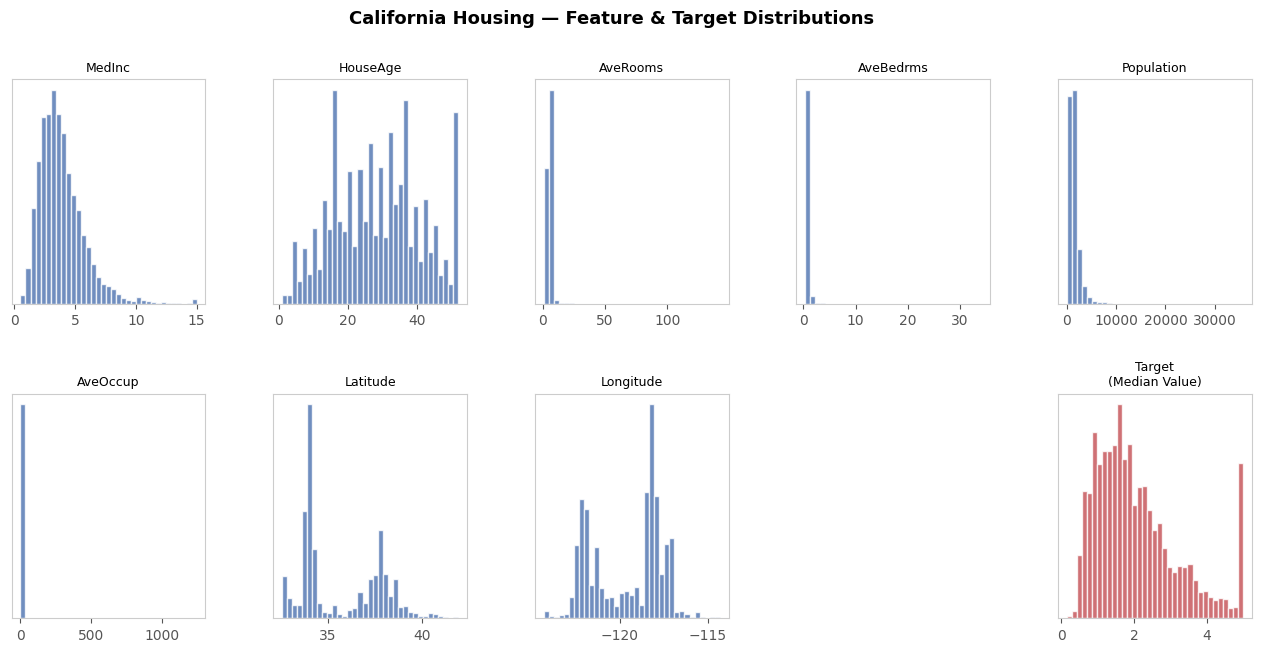

In [3]:
fig = plt.figure(figsize=(16, 7))
gs  = fig.add_gridspec(2, 5, hspace=0.4, wspace=0.35)

for idx, col in enumerate(feature_names):
    r, c = divmod(idx, 5)
    ax = fig.add_subplot(gs[r, c])
    ax.hist(X[col], bins=35, color='#4c72b0', alpha=0.8, edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_yticks([])

ax_t = fig.add_subplot(gs[1, 4])
ax_t.hist(y, bins=35, color='#c44e52', alpha=0.8, edgecolor='white')
ax_t.set_title('Target\n(Median Value)', fontsize=9)
ax_t.set_yticks([])

fig.suptitle('California Housing â€” Feature & Target Distributions', fontsize=13, fontweight='bold')
plt.show()

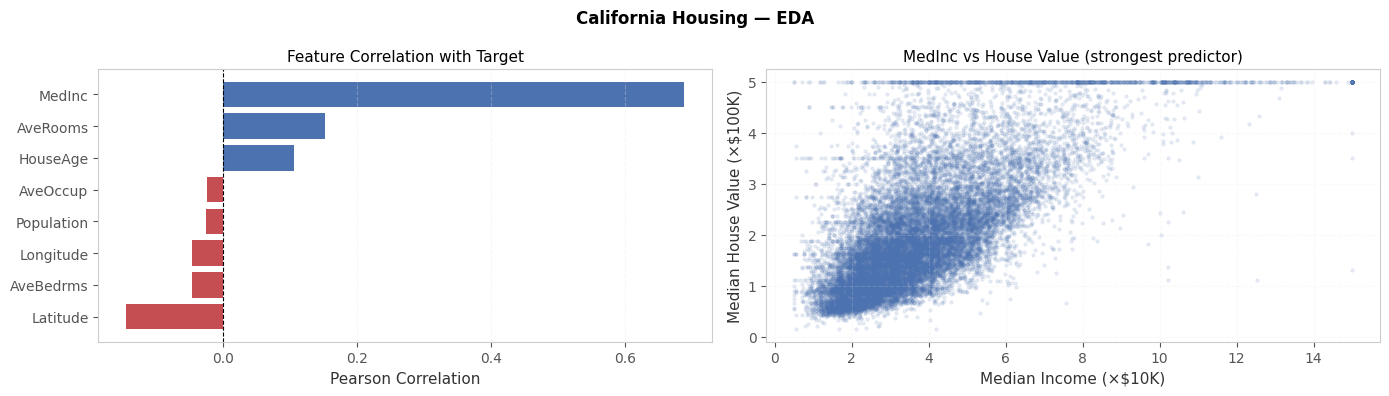

In [4]:
corr_with_target = X.corrwith(y).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ['#4c72b0' if v >= 0 else '#c44e52' for v in corr_with_target.values]
axes[0].barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors[::-1])
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Feature Correlation with Target', fontsize=11)
axes[0].set_xlabel('Pearson Correlation')
axes[0].grid(axis='x', alpha=0.3)

axes[1].scatter(X['MedInc'], y, alpha=0.1, s=5, color='#4c72b0')
axes[1].set_xlabel('Median Income (Ã—$10K)')
axes[1].set_ylabel('Median House Value (Ã—$100K)')
axes[1].set_title('MedInc vs House Value (strongest predictor)', fontsize=11)
axes[1].grid(alpha=0.2)

plt.suptitle('California Housing â€” EDA', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (16512, 8)  |  Test: (4128, 8)


## 3. CatBoost Regression with Boostwatch

### Two-tier monitoring

Because CatBoost does not expose split-level tree structure through callbacks, boostwatch uses two steps:

```python
# Step 1 â€” capture eval metrics live during training
observer = watch(model, feature_names=feature_names)
model.fit(X_train, y_train, eval_set=(X_test, y_test),
          callbacks=observer.callbacks())

# Step 2 â€” extract tree structure post-fit
observer.finalize(model)
```

After `finalize()`, each `IterationLog` contains leaf counts and feature importance derived from CatBoost's post-training API.

In [ ]:
cb_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
)

observer = watch(cb_model, feature_names=feature_names)

print('Training CatBoost (200 iterations)...')
cb_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    callbacks=observer.callbacks(),
)

# Back-fill tree structure from post-training model inspection
observer.finalize(cb_model)

cb_preds = cb_model.predict(X_test)
cb_rmse  = root_mean_squared_error(y_test, cb_preds)
cb_mae   = mean_absolute_error(y_test, cb_preds)
cb_r2    = r2_score(y_test, cb_preds)

print(f'Iterations logged   : {len(observer.get_logs())}')
print(f'Trees with structure: {sum(1 for l in observer.get_logs() if l.trees)}')
print(f'RMSE                : {cb_rmse:.4f}  (Ã—$100K = ${cb_rmse*100:.0f}K)')
print(f'MAE                 : {cb_mae:.4f}  (Ã—$100K = ${cb_mae*100:.0f}K)')
print(f'RÂ²                  : {cb_r2:.4f}')

Training CatBoost (200 iterations)...


Iterations logged   : 200
Trees with structure: 200
RMSE                : 0.5185  (Ã—$100K = $52K)
MAE                 : 0.3513  (Ã—$100K = $35K)
RÂ²                  : 0.7948


### 3a. Live Eval Metrics

The first tier of boostwatch monitoring â€” eval metrics captured at every iteration from the callback, identical to how LightGBM and XGBoost work.

Captured metrics: ['learn-RMSE', 'validation-RMSE']


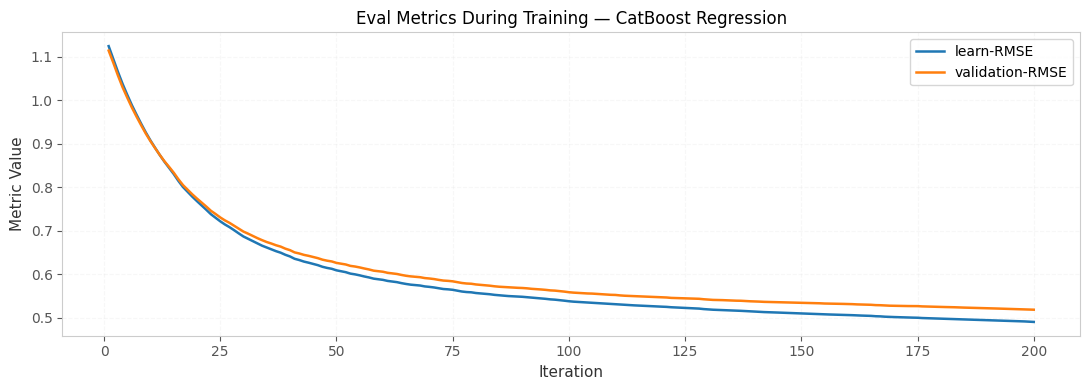

In [7]:
# Plot eval metrics from observer logs
metric_keys = list(observer.get_logs()[0].metrics.keys())
print(f'Captured metrics: {metric_keys}')

fig, ax = plt.subplots(figsize=(11, 4))
for key in metric_keys:
    iters  = [log.iteration for log in observer.get_logs() if key in log.metrics]
    values = [log.metrics[key] for log in observer.get_logs() if key in log.metrics]
    ax.plot(iters, values, linewidth=1.8, label=key)

ax.set_xlabel('Iteration')
ax.set_ylabel('Metric Value')
ax.set_title('Eval Metrics During Training â€” CatBoost Regression', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3b. Training Summary

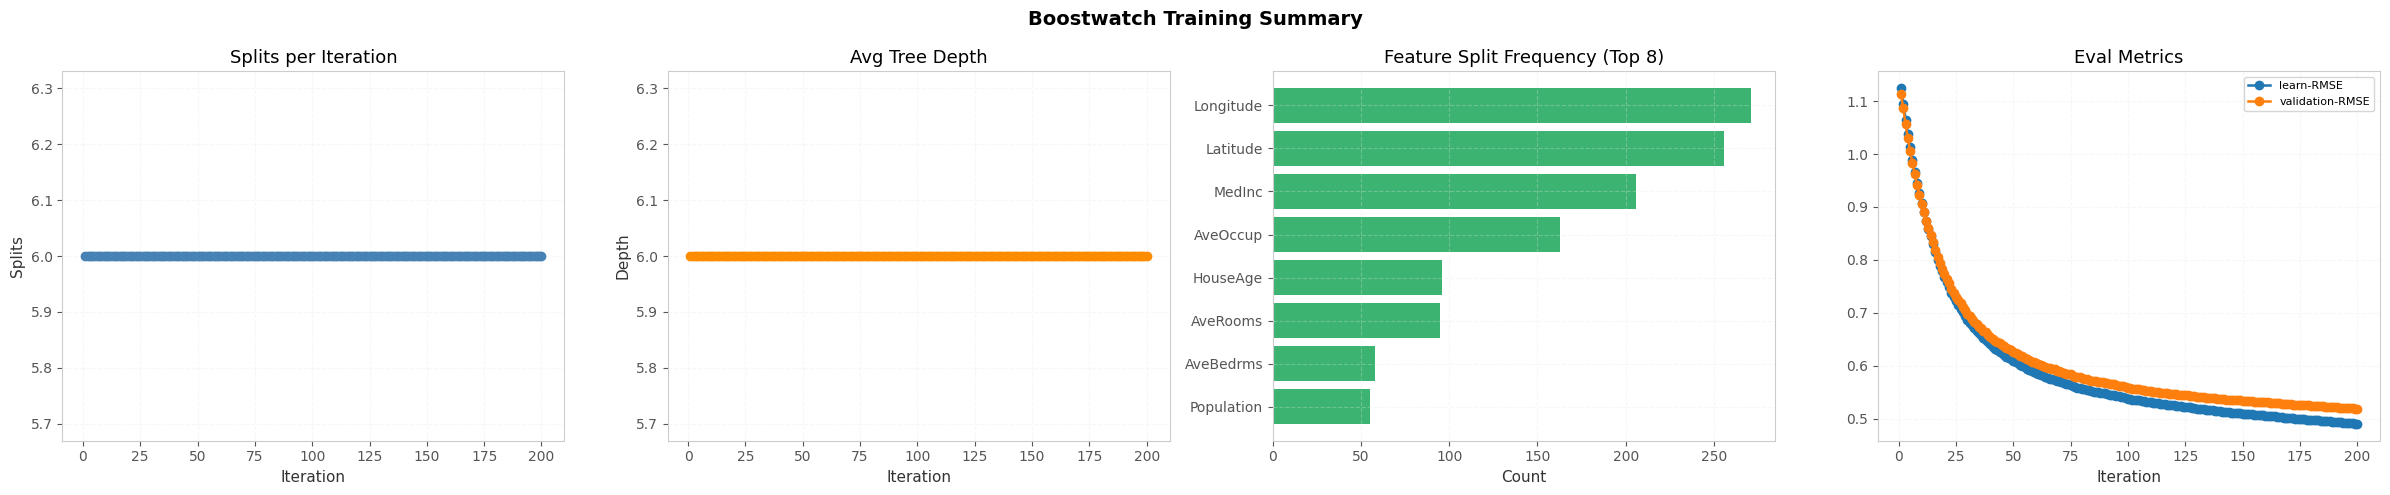

In [8]:
observer.plot_summary()

### 3c. Feature Importance

After `finalize()`, boostwatch calls `model._object._get_tree_splits(tree_idx, None)` for each
tree to read the exact **feature index** and **threshold** at every split level.

CatBoost's oblivious trees use one feature per depth level: if tree `t1` splits on
`[MedInc, MedInc, AveOccup]` and tree `t2` splits on `[MedInc, Latitude, Longitude]`, then
`MedInc` gets count=3, `AveOccup`/`Latitude`/`Longitude` each get count=1.

Split count across all trees is the primary importance signal.
`avg_gain` is a proxy: `global_importance / split_count` per feature.

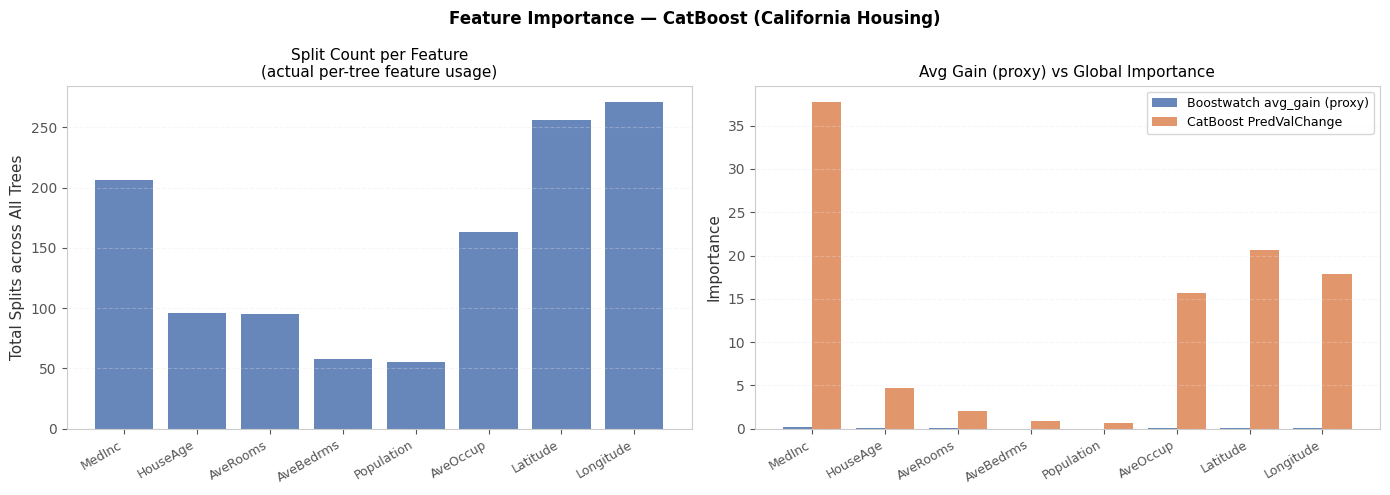

Feature usage across all 200 trees:
  MedInc      :  206 splits, avg_gain=0.183
  HouseAge    :   96 splits, avg_gain=0.048
  AveRooms    :   95 splits, avg_gain=0.021
  AveBedrms   :   58 splits, avg_gain=0.015
  Population  :   55 splits, avg_gain=0.011
  AveOccup    :  163 splits, avg_gain=0.096
  Latitude    :  256 splits, avg_gain=0.080
  Longitude   :  271 splits, avg_gain=0.066


In [9]:
stats = observer.feature_stats()

bw_counts = [stats.get(i, {}).get('count',    0) for i in range(len(feature_names))]
bw_gains  = [stats.get(i, {}).get('avg_gain', 0) for i in range(len(feature_names))]
cb_importance = cb_model.get_feature_importance()

x = np.arange(len(feature_names))
w = 0.4

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Split count per feature: how many times each feature was chosen across all 200 trees
axes[0].bar(x, bw_counts, color='#4c72b0', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(feature_names, rotation=30, ha='right', fontsize=9)
axes[0].set_title('Split Count per Feature\n(actual per-tree feature usage)', fontsize=11)
axes[0].set_ylabel('Total Splits across All Trees')
axes[0].grid(axis='y', alpha=0.3)

# avg_gain proxy vs CatBoost built-in global importance
axes[1].bar(x - w/2, bw_gains,      w, label='Boostwatch avg_gain (proxy)', color='#4c72b0', alpha=0.85)
axes[1].bar(x + w/2, cb_importance, w, label='CatBoost PredValChange',      color='#dd8452', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(feature_names, rotation=30, ha='right', fontsize=9)
axes[1].set_title('Avg Gain (proxy) vs Global Importance', fontsize=11)
axes[1].set_ylabel('Importance')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Importance â€” CatBoost (California Housing)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Feature usage across all 200 trees:')
for i, name in enumerate(feature_names):
    print('  {:12s}: {:4d} splits, avg_gain={:.3f}'.format(name, bw_counts[i], bw_gains[i]))

### 3d. Tree Structure Analysis

Each iteration log contains one `TreeLog` with per-level splits, actual leaf sample counts
(`leaf_weights`), and leaf output values â€” all from `model._object` internals.

CatBoost uses symmetric (oblivious) trees: every node at depth `d` splits on the same feature
with the same threshold. This means `depth = logâ‚‚(num_leaves)` exactly, and the per-level
feature choice is recorded as `SplitInfo` entries (ordered from root to leaves).

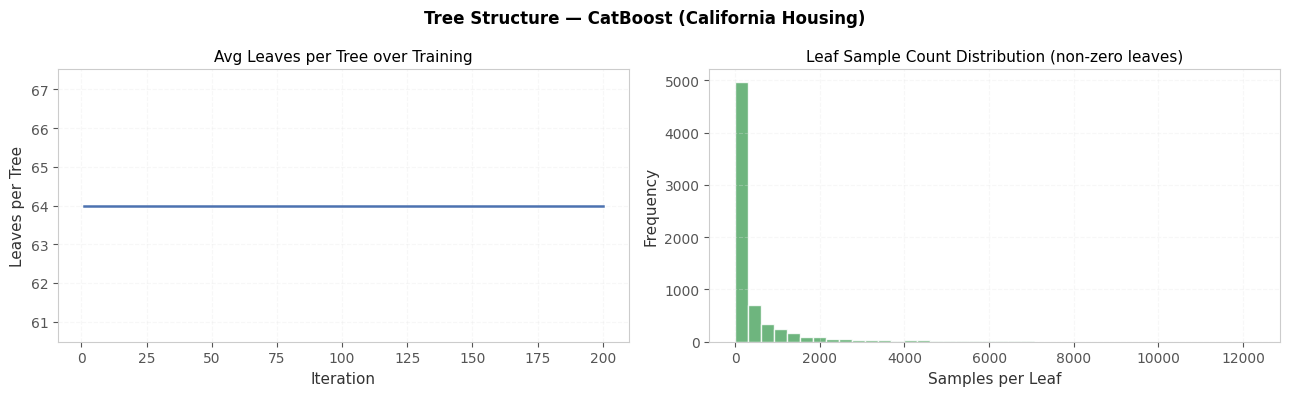

Tree depth=6, leaves=64, splits per tree=6

Iteration 0 split structure:
  depth=0: MedInc <= 5.7436
  depth=1: MedInc <= 3.0886
  depth=2: AveOccup <= 2.3749
  depth=3: Latitude <= 38.0250
  depth=4: Longitude <= -118.2450
  depth=5: Latitude <= 34.3550


In [10]:
ts = compute_tree_stats(observer.get_logs())
ld = compute_leaf_distribution(observer.get_logs())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

if ts['iterations']:
    axes[0].plot(ts['iterations'], ts['avg_leaves'], color='#4c72b0', linewidth=1.8)
    axes[0].set_title('Avg Leaves per Tree over Training', fontsize=11)
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Leaves per Tree')
    axes[0].grid(alpha=0.3)
else:
    axes[0].text(0.5, 0.5, 'No tree structure (call finalize() first)',
                 ha='center', va='center', transform=axes[0].transAxes)

if ld['leaf_counts']:
    non_zero = [c for c in ld['leaf_counts'] if c > 0]
    axes[1].hist(non_zero, bins=40, color='#55a868', edgecolor='white', alpha=0.85)
    axes[1].set_title('Leaf Sample Count Distribution (non-zero leaves)', fontsize=11)
    axes[1].set_xlabel('Samples per Leaf')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(alpha=0.3)

plt.suptitle('Tree Structure â€” CatBoost (California Housing)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

if ts['iterations']:
    print('Tree depth={}, leaves={}, splits per tree={}'.format(
          int(ts['avg_depth'][0]), int(ts['avg_leaves'][0]), int(ts['total_splits'][0])))

# Show splits for first iteration as example
log0 = observer.get_logs()[0]
if log0.trees:
    print('\nIteration 0 split structure:')
    for sp in log0.trees[0].splits:
        print('  depth={}: {} <= {:.4f}'.format(sp.depth, sp.feature_name, sp.threshold))

## 4. Residual & Prediction Quality

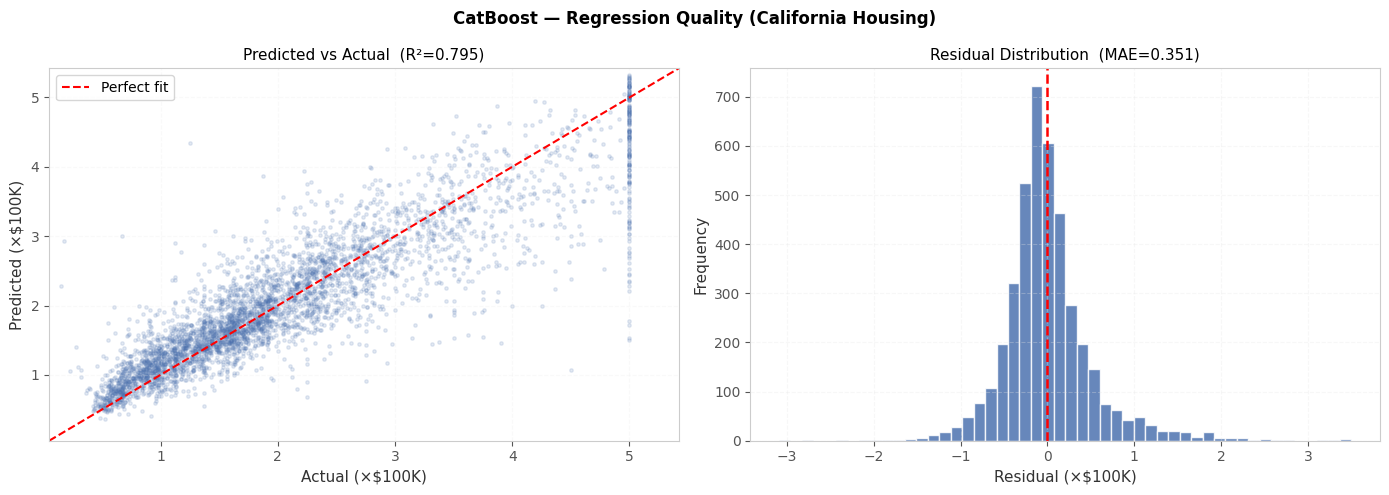

In [11]:
cb_resid = y_test.values - cb_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lim = (min(y_test.min(), cb_preds.min()) - 0.1, max(y_test.max(), cb_preds.max()) + 0.1)
axes[0].scatter(y_test, cb_preds, alpha=0.15, s=6, color='#4c72b0')
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlim(lim)
axes[0].set_ylim(lim)
axes[0].set_xlabel('Actual (Ã—$100K)')
axes[0].set_ylabel('Predicted (Ã—$100K)')
axes[0].set_title(f'Predicted vs Actual  (RÂ²={cb_r2:.3f})', fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].hist(cb_resid, bins=50, color='#4c72b0', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Ã—$100K)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution  (MAE={cb_mae:.3f})', fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('CatBoost â€” Regression Quality (California Housing)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()